### MISY408 - Project 6

### Titanic Dataset

**Attributes**

* Survived: 0 = Not survived, 1 = Survived
* Pclass: Ticket class 1 = 1st class, 2 = 2nd class, 3 = 3rd class
* Name: Name of passenger
* Sex: male, female
* Age: Age of passenger
* Sibsp: # of siblings / spouses aboard the Titanic
* Parch: # of parents / children aboard the Titanic
* Ticket: Ticket number
* Fare: Passenger fare
* Cabin: Cabin number
* Embarked: Port of Embarkation C = Cherbourg, Q = Queenstown, S = Southampton

**Question1: Import the required libraries and read Titanic.csv file and save it in df dataframe, display the first five rows of df dataframe**

In [83]:
import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import seaborn as sns
from sklearn import tree
import matplotlib.pyplot as plt

df = pd.read_csv('Titanic.csv')
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


**Question 2: Exploratory data analysis. For this part you should:**

a. Check the shape of dataset

In [84]:
df.shape

(891, 12)

b. Check if there is any missing values in the df dataframe

In [85]:
df.isnull().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

c. drop the rows with missing values

In [86]:
df.dropna(inplace=True)

d. View the statistical summary of numerical variables in df dataframe (describe() method)

In [87]:
df.describe().transpose()

,count,mean,std,min,25%,50%,75%,max
PassengerId,183.0,455.366120,247.052476,2.00,263.5,457.0,676.0,890.0000
Survived,183.0,0.672131,0.470725,0.00,0.0,1.0,1.0,1.0000
Pclass,183.0,1.191257,0.515187,1.00,1.0,1.0,1.0,3.0000
Age,183.0,35.674426,15.643866,0.92,24.0,36.0,47.5,80.0000
SibSp,183.0,0.464481,0.644159,0.00,0.0,0.0,1.0,3.0000
Parch,183.0,0.475410,0.754617,0.00,0.0,0.0,1.0,4.0000
Fare,183.0,78.682469,76.347843,0.00,29.7,57.0,90.0,512.3292


**Question 3:** 

a. Create a frequency table to show the number of survived and number of not-survived passengers

In [88]:
freqtb=df['Survived'].value_counts().reset_index()
freqtb.columns=['Survived', 'Count']
print(freqtb)

   Survived  Count
0         1    123
1         0     60


b. In the following, interpret the above frequency table's output.

Our frequency table above tells us that 123 people did not survive while 60 people did survive

c. In the following, type a code to calculate average Fare and average Age for each Survived group (there should be only one table in the output)

In [89]:
df.loc[df["Survived"] == 1] [["Fare", "Age"]].groupby(df["Pclass"]).mean()


,Fare,Age
Pclass,,
1,96.814192,34.952075
2,18.940975,20.791667
3,13.280000,18.600000


d. In the following, interpret the above output. How  average Fare and average Age are different for different Survived groups.

For the surviving first class the average fare was 96.81 and were around the age of 35, for the surviving second class the avg fare was 18.94 and were around 21 years old, lastly the third class fare was about 13 and the average age was 19 

e. Create a crosstab to show the number of survived and the number of not-survived passengers for each Sex

In [90]:
pd.crosstab(df['Survived'], df['Sex'])

Sex,female,male
Survived,,
0,6,54
1,82,41


f. In the following, interpret the above output.

54 maales & 6 females did not survive, while 82 females & 41 males did survive 

**Question 4:**

a. Use Sex and Age as X variables and use 'Survived' as Y variable.

(**Note:** Since Sex is categorical variable, you should code it before using it. For example: create SexCode and set male to 0 and female to 1)

In [95]:
df['SexCode'] = df['Sex'].map({'male': 0, 'female': 1})
X = df[['SexCode', 'Age']]
Y = df['Survived']

b. Create a Decision Tree with the X and Y variables

[Text(0.5, 0.8333333333333334, 'SexCode <= 0.5\ngini = 0.465\nsamples = 128\nvalue = [47, 81]'),
 Text(0.25, 0.5, 'Age <= 14.5\ngini = 0.483\nsamples = 71\nvalue = [42, 29]'),
 Text(0.125, 0.16666666666666666, 'gini = 0.0\nsamples = 5\nvalue = [0, 5]'),
 Text(0.375, 0.16666666666666666, 'gini = 0.463\nsamples = 66\nvalue = [42, 24]'),
 Text(0.75, 0.5, 'Age <= 3.0\ngini = 0.16\nsamples = 57\nvalue = [5, 52]'),
 Text(0.625, 0.16666666666666666, 'gini = 0.0\nsamples = 2\nvalue = [2, 0]'),
 Text(0.875, 0.16666666666666666, 'gini = 0.103\nsamples = 55\nvalue = [3, 52]')]

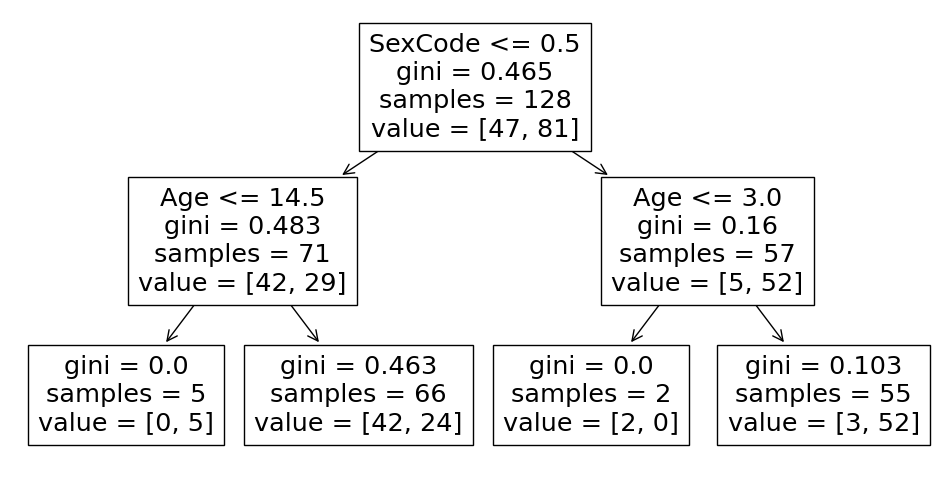

In [99]:
from sklearn.model_selection import train_test_split
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size = 0.3, random_state = 0) 

Y_train.value_counts(sort=False)
Y_test.value_counts(sort=False)

from sklearn import tree
clf= tree.DecisionTreeClassifier(max_depth=2, random_state = 0)
clf= clf.fit(X_train,Y_train)

plt.figure(figsize=(12,6))
tree.plot_tree(clf,feature_names=['SexCode','Age'])

c. Interpet the decision tree in the following cell (For interpretation: make sure to use the same template as the class notebooks) 

We have a total of 128 people in our data. For males 59.15% of them did not survive while 40.85% did survive. For those who were less or equal to 14.5 years of age and male 0% died and 100% did survive. For those who were greater than 14.5 years old and were male, 63.64% did not survie and 36.36% did survive. For females 8.77% died while 91.23% survived, For those who were not less than 3 years old but were females 5.45% died and 94.55% survived. For those who were less than 3 years old and were females 100% of them died and 0% survived. 

d. Based on Gini score which node has the best classification (has lower impurity)? and which node has the worst classification (has higher impurity)? explain why?

The node with the best gini is the one with 0 and the worst node is the one with .483

**Question 5:**

a. In the following, type a code to show the importance of each feature. 

In [100]:
clf.feature_importances_

array([0.68991557, 0.31008443])

b. In the following, Interpret the feature importance output

SexCode or Sex has a 68.99% importance while Age has a 31% importance at determining if they survived or not

**Question 6:**

a. In the following, type a code to create a confusion matrix

In [101]:
from sklearn.metrics import confusion_matrix
predictions= clf.predict(X_train)
cm = confusion_matrix(Y_train, predictions)
cm

array([[44,  3],
       [24, 57]])

b. In the following, Interpret the confusion matrix. (please use the same template as the class notebooks)

People who didn't survive, we predicted 44 of them correctly and 3 of them we said would survive but they didn't. Of people who did survive, we correctly predicted that 57 correctly that they would survive, but falsely predicted that 24 would die.  

**Question 7: In the following, type a code to show the accuracy of your model? (please use a print statement with placeholders to print the percentage of accuracy)**

In [102]:
accuracy = clf.score(X,Y) 
print("Your decision tree is {:.2f}% accurate.".format(accuracy*100))

Your decision tree is 79.23% accurate.
